# F1 Pit Stops Prediction - EDA (Exploratory Data Analysis)

이 노트북은 **Kaggle Playground Series Season 6, Episode 5: Predicting F1 Pit Stops** 경진대회 데이터셋의 특성을 파악하고, 모델링 및 피처 엔지니어링 전략을 세우기 위한 탐색적 데이터 분석(EDA) 템플릿입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.family'] = 'DejaVu Sans'

# 데이터 로드 경로 설정
train_path = "./train.csv"
test_path = "./test.csv"

print("Loading datasets...")
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print("Datasets Loaded Successfully!")

Loading datasets...
Datasets Loaded Successfully!


## 1. 데이터 기본 정보 및 크기 확인

In [3]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

print("\n--- Train Data Missing Values ---")
print(train.isnull().sum())
print("\n--- Test Data Missing Values ---")
print(test.isnull().sum())

Train shape: (439140, 16)
Test shape: (188165, 15)

--- Train Data Missing Values ---
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

--- Test Data Missing Values ---
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0

## 2. 타겟 변수 (`PitNextLap`) 분포 확인

다음 랩에 피트스탑을 수행할 확률(1)과 수행하지 않을 확률(0)의 비율을 시각화합니다.

Target Counts:
 PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64
Target Percentages:
 PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64


/tmp/ipykernel_202724/1685368537.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pit_counts.index, y=pit_counts.values, palette="viridis")


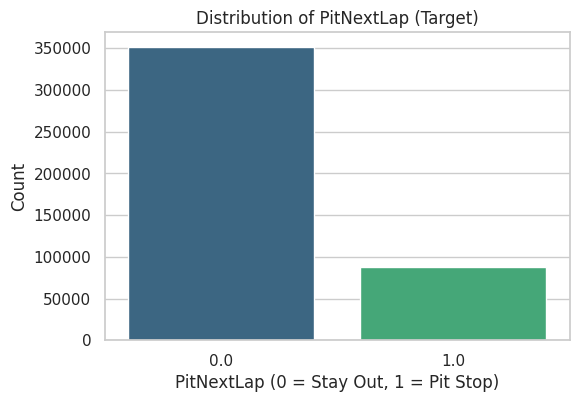

In [4]:
pit_counts = train['PitNextLap'].value_counts()
pit_pct = train['PitNextLap'].value_counts(normalize=True) * 100

print("Target Counts:\n", pit_counts)
print("Target Percentages:\n", pit_pct)

plt.figure(figsize=(6, 4))
sns.barplot(x=pit_counts.index, y=pit_counts.values, palette="viridis")
plt.title("Distribution of PitNextLap (Target)")
plt.xlabel("PitNextLap (0 = Stay Out, 1 = Pit Stop)")
plt.ylabel("Count")
plt.show()

## 3. 수치형 피처들과 타겟과의 상관관계 분석

Correlations with PitNextLap:
PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64


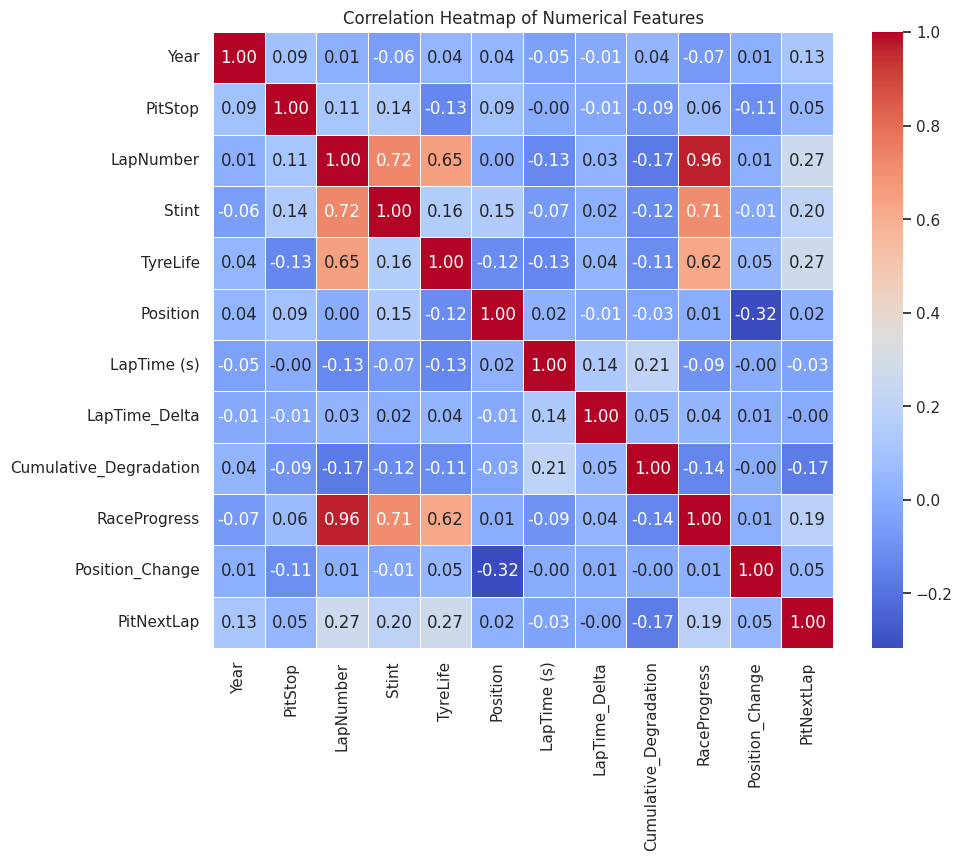

In [5]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numeric_cols: numeric_cols.remove('id')

# 타겟과의 상관관계 계산
correlations = train[numeric_cols].corr()['PitNextLap'].sort_values(ascending=False)
print("Correlations with PitNextLap:")
print(correlations)

# 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 4. 타이어 종류(`Compound`)와 수명(`TyreLife`)에 따른 피트스탑 분석

실제 타이어 마모에 따른 피트스탑 성향은 컴파운드(HARD, MEDIUM, SOFT 등) 마다 다릅니다. 각 컴파운드별로 피트스탑(Target=1)을 수행했을 때의 `TyreLife` 분포를 살펴봅니다.

--- Statistics of TyreLife at Pit Stop by Compound ---
                count       mean        std  min   50%   max
Compound                                                    
HARD          55851.0  21.458640  10.683807  1.0  20.0  77.0
INTERMEDIATE   2647.0  18.043068   9.044508  1.0  17.0  59.0
MEDIUM        21353.0  17.136562   9.131501  1.0  16.0  76.0
SOFT           7496.0  12.612727   6.656589  1.0  12.0  50.0
WET              34.0  13.029412   6.191320  4.0  11.0  27.0


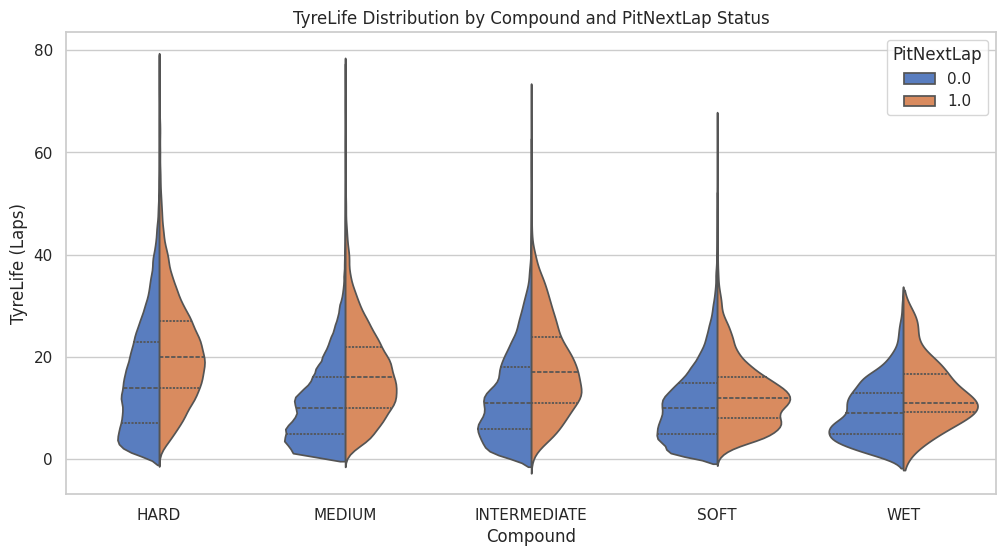

In [6]:
# 컴파운드별 피트스탑 시점의 TyreLife 통계
pit_in = train[train['PitNextLap'] == 1]

print("--- Statistics of TyreLife at Pit Stop by Compound ---")
print(pit_in.groupby('Compound')['TyreLife'].describe()[['count', 'mean', 'std', 'min', '50%', 'max']])

# 바이올린 플롯으로 분포 시각화
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='Compound', y='TyreLife', hue='PitNextLap', split=True, inner="quart", palette="muted")
plt.title("TyreLife Distribution by Compound and PitNextLap Status")
plt.xlabel("Compound")
plt.ylabel("TyreLife (Laps)")
plt.show()

## 5. 서킷별(`Race`) 피트스탑 성향 분석

서킷마다 전체 랩 수 및 피트스탑 횟수가 다릅니다. 상위 서킷들의 피트스탑 확률 분포를 비교합니다.

/tmp/ipykernel_202724/2751711121.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_pit_rate.index, y=race_pit_rate.values, palette="flare")


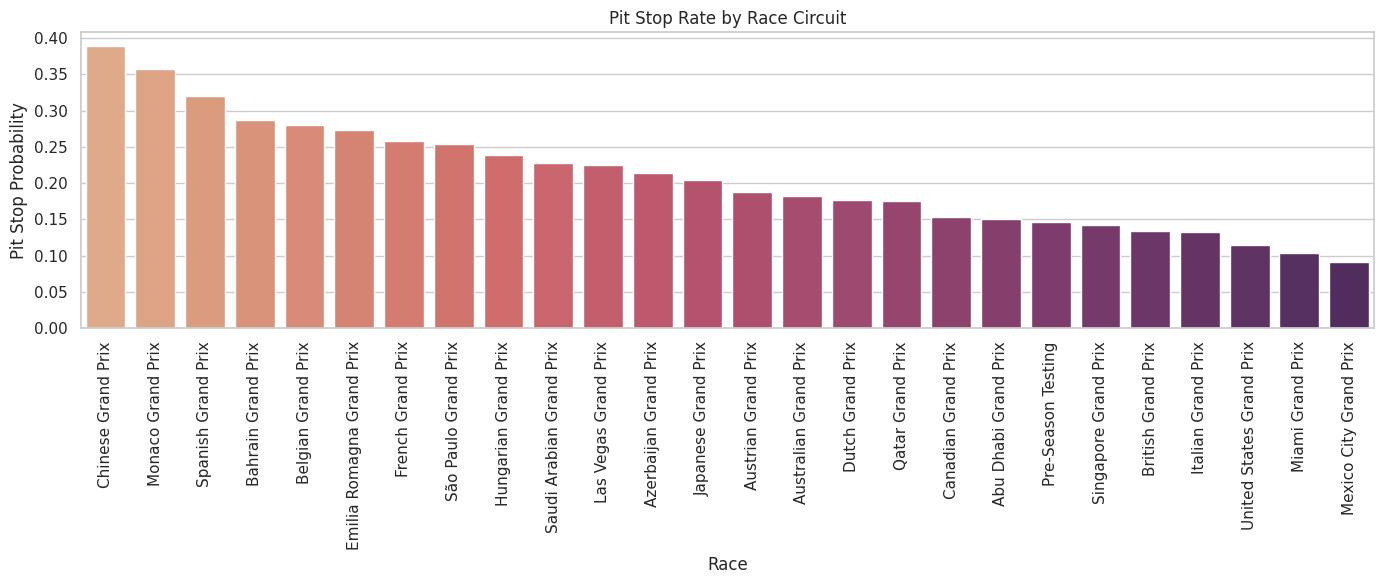

In [7]:
race_pit_rate = train.groupby('Race')['PitNextLap'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=race_pit_rate.index, y=race_pit_rate.values, palette="flare")
plt.xticks(rotation=90)
plt.title("Pit Stop Rate by Race Circuit")
plt.xlabel("Race")
plt.ylabel("Pit Stop Probability")
plt.tight_layout()
plt.show()

## 6. 피처 엔지니어링 아이디어 도출을 위한 팁

1. **타이어 소모 비율(Tyre Wear Ratio) 생성**
   * 컴파운드별 평균 피트인 시점(`TyreLife` 중간값/평균) 대비 현재 `TyreLife` 비율을 피처로 사용해 보세요.
   * 예: `TyreLife` / (컴파운드별 평균 피트인 TyreLife)
   
2. **서킷 특성 반영**
   * 서킷(`Race`)별 평균 랩 타임, 평균 피트인 랩(`TyreLife`) 등을 계산해 정규화에 사용해 보세요.
   
3. **누적 감쇠율(Cumulative Degradation) 분석**
   * `Cumulative_Degradation`과 `LapTime_Delta`를 활용하여 차량의 속도가 얼마나 느려지고 있는지에 대한 트렌드 피처를 만들어 보세요.